In [1]:
import os
import pickle
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from datetime import datetime

sns.set(style="whitegrid")

In [2]:
BASE_DIR = os.path.abspath("..")
DATA_PATH = os.path.join(BASE_DIR, "data", "final_master_report.csv")
MODEL_DIR = os.path.join(BASE_DIR, "models")
MODEL_PATH = os.path.join(MODEL_DIR, "ev_forecast_model_v2.pkl")

os.makedirs(MODEL_DIR, exist_ok=True)

In [3]:
df = pd.read_csv(DATA_PATH)
print("Dataset Loaded:", df.shape)

Dataset Loaded: (970, 6)


In [4]:
def categorize_fuel(fuel):
    fuel = str(fuel).upper()
    if "EV" in fuel or "ELECTRIC" in fuel:
        return "EV"
    if "HYBRID" in fuel:
        return "HYBRID"
    if "CNG" in fuel:
        return "CNG"
    if "PETROL" in fuel:
        return "PETROL"
    if "DIESEL" in fuel:
        return "DIESEL"
    return "OTHER"

df["Category"] = df["Fuel"].apply(categorize_fuel)

In [5]:
year_cols = sorted([c for c in df.columns if c.isdigit()], key=int)

ev_df = df[df["Category"] == "EV"]

X = np.array([int(y) for y in year_cols]).reshape(-1, 1)
y = ev_df[year_cols].sum().values

**Linear Regression (BASE MODEL)**

In [6]:
lin_model = LinearRegression()
lin_model.fit(X, y)

y_pred_lin = lin_model.predict(X)

lin_r2 = r2_score(y, y_pred_lin)
lin_mae = mean_absolute_error(y, y_pred_lin)
lin_rmse = np.sqrt(mean_squared_error(y, y_pred_lin))

**Polynomial Regression**

In [7]:
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

poly_model = LinearRegression()
poly_model.fit(X_poly, y)

y_pred_poly = poly_model.predict(X_poly)

poly_r2 = r2_score(y, y_pred_poly)
poly_mae = mean_absolute_error(y, y_pred_poly)
poly_rmse = np.sqrt(mean_squared_error(y, y_pred_poly))

**ARIMA (Experimental)**

In [8]:
arima = ARIMA(y, order=(1, 1, 1))
arima_res = arima.fit()

y_pred_arima = arima_res.predict(start=1, end=len(y)-1)
y_actual_arima = y[1:]

min_len = min(len(y_actual_arima), len(y_pred_arima))
y_actual_arima = y_actual_arima[:min_len]
y_pred_arima = y_pred_arima[:min_len]

arima_r2 = r2_score(y_actual_arima, y_pred_arima)
arima_mae = mean_absolute_error(y_actual_arima, y_pred_arima)
arima_rmse = np.sqrt(mean_squared_error(y_actual_arima, y_pred_arima))

E:\Anaconda\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


**GRAPH SECTION**

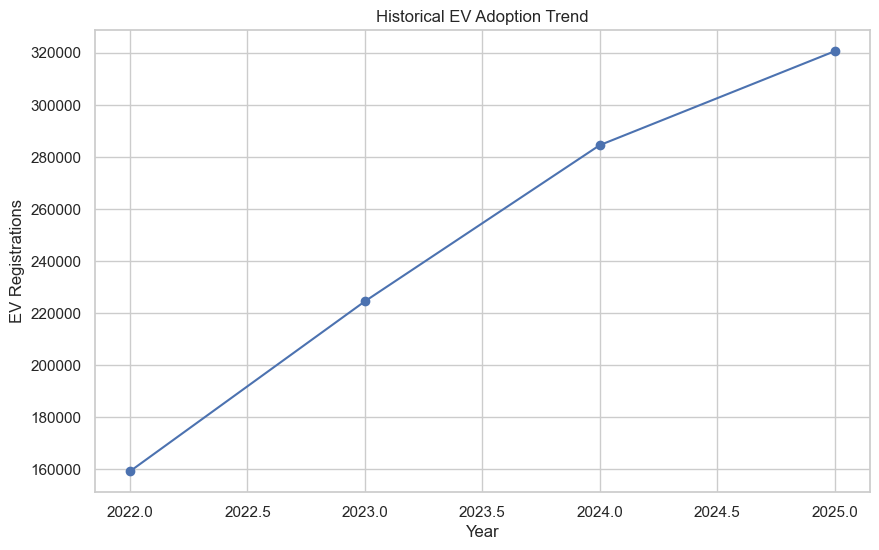

In [9]:
plt.figure(figsize=(10,6))
plt.plot(X.flatten(), y, marker="o")
plt.title("Historical EV Adoption Trend")
plt.xlabel("Year")
plt.ylabel("EV Registrations")
plt.show()

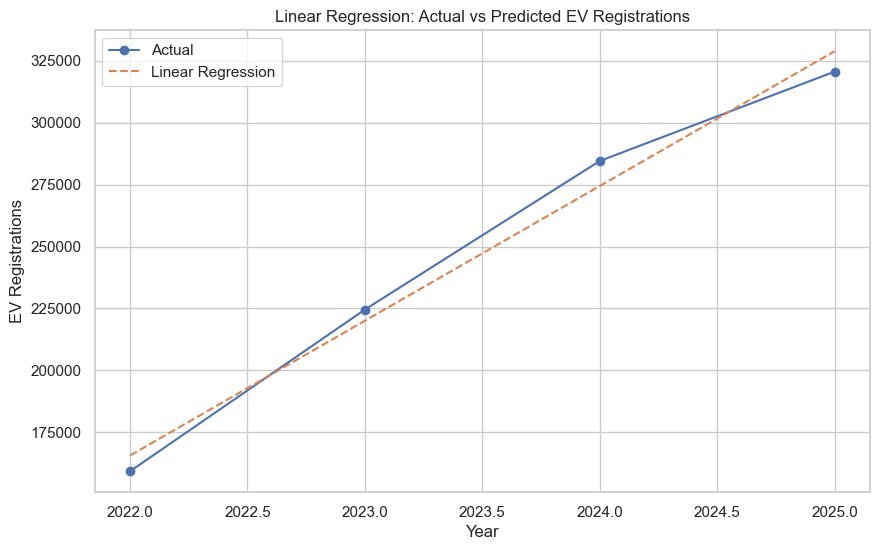

In [10]:
plt.figure(figsize=(10,6))
plt.plot(X.flatten(), y, marker="o", label="Actual")
plt.plot(X.flatten(), y_pred_lin, "--", label="Linear Regression")
plt.title("Linear Regression: Actual vs Predicted EV Registrations")
plt.xlabel("Year")
plt.ylabel("EV Registrations")
plt.legend()
plt.show()

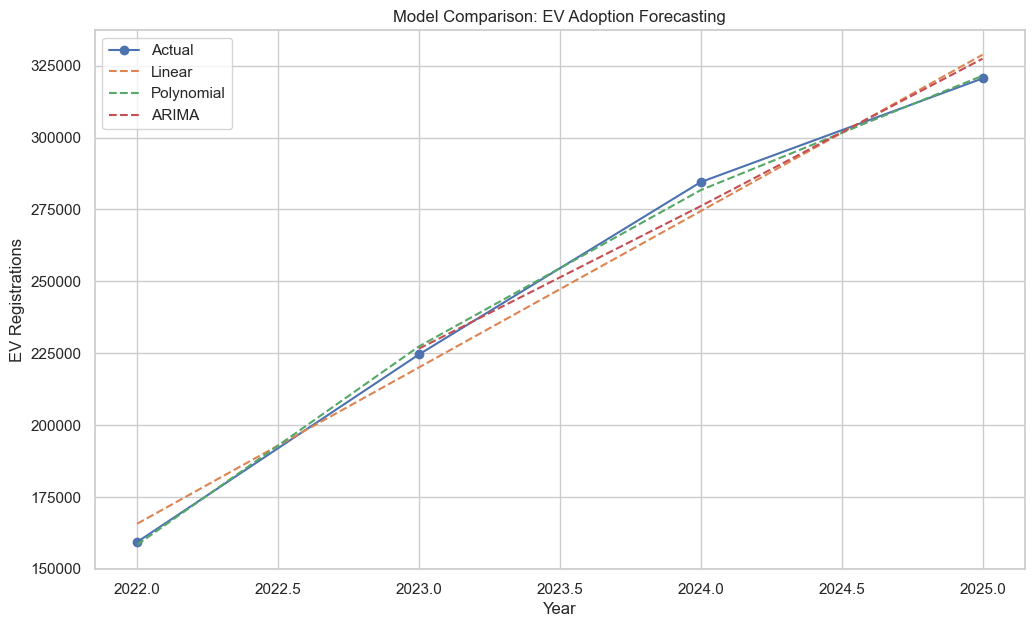

In [11]:
plt.figure(figsize=(12,7))
plt.plot(X.flatten(), y, marker="o", label="Actual")
plt.plot(X.flatten(), y_pred_lin, "--", label="Linear")
plt.plot(X.flatten(), y_pred_poly, "--", label="Polynomial")
plt.plot(X.flatten()[1:1+min_len], y_pred_arima, "--", label="ARIMA")

plt.title("Model Comparison: EV Adoption Forecasting")
plt.xlabel("Year")
plt.ylabel("EV Registrations")
plt.legend()
plt.show()

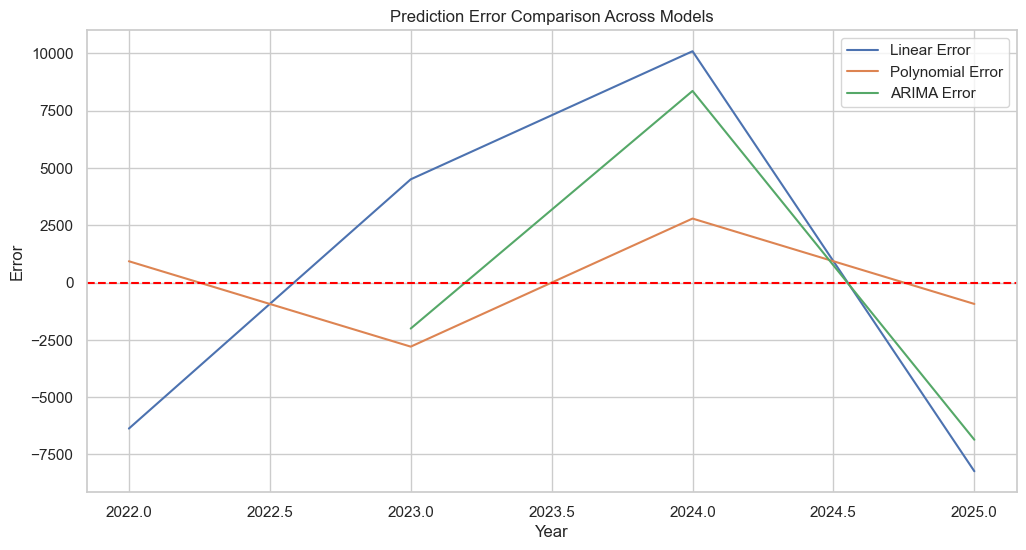

In [12]:
plt.figure(figsize=(12,6))
plt.plot(X.flatten(), y - y_pred_lin, label="Linear Error")
plt.plot(X.flatten(), y - y_pred_poly, label="Polynomial Error")
plt.plot(X.flatten()[1:1+min_len], y_actual_arima - y_pred_arima, label="ARIMA Error")
plt.axhline(0, color="red", linestyle="--")
plt.title("Prediction Error Comparison Across Models")
plt.xlabel("Year")
plt.ylabel("Error")
plt.legend()
plt.show()

**SAVE MODEL**

In [13]:
model_bundle = {
    "linear": lin_model,
    "poly": {
        "model": poly_model,
        "transformer": poly
    },
    "arima": arima_res,
    "metrics": {
        "linear": {"r2": lin_r2, "mae": lin_mae, "rmse": lin_rmse},
        "poly": {"r2": poly_r2, "mae": poly_mae, "rmse": poly_rmse},
        "arima": {"r2": arima_r2, "mae": arima_mae, "rmse": arima_rmse},
    },
    "trained_on": datetime.now().isoformat(),
    "years": X.flatten().tolist()
}

with open(MODEL_PATH, "wb") as f:
    pickle.dump(model_bundle, f)

print("Saved:", MODEL_PATH)

Saved: E:\JupyterProject\EV-Infrastructure-Intelligence\models\ev_forecast_model_v2.pkl
